In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataraw/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nColumns:\n{list(df.columns)}")

Shape: (1470, 35)

Dtypes:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel            

In [4]:
# TARGET: Attrition (nhân viên có rời không)
# DURATION: YearsAtCompany (thời gian sống sót)
# TREATMENT: TrainingTimesLastYear (số lần training năm ngoái)

print("=== TARGET: Attrition ===")
print(df['Attrition'].value_counts())
print(f"Attrition rate: {(df['Attrition']=='Yes').mean():.1%}")

print("\n=== DURATION: YearsAtCompany ===")
print(df['YearsAtCompany'].describe())

print("\n=== TREATMENT: TrainingTimesLastYear ===")
print(df['TrainingTimesLastYear'].value_counts().sort_index())
print(f"\nMean training: {df['TrainingTimesLastYear'].mean():.2f}")

# Định nghĩa treatment binary: >= 3 lần training = "treated"
# Lý do: median là ngưỡng tự nhiên phân chia 2 nhóm có ý nghĩa
threshold = df['TrainingTimesLastYear'].median()
df['Trained'] = (df['TrainingTimesLastYear'] >= threshold).astype(int)
print(f"\nThreshold training: >= {threshold} lần")
print(f"Treated (1): {df['Trained'].sum()} nhân viên")
print(f"Control (0): {(df['Trained']==0).sum()} nhân viên")

=== TARGET: Attrition ===
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition rate: 16.1%

=== DURATION: YearsAtCompany ===
count    1470.000000
mean        7.008163
std         6.126525
min         0.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        40.000000
Name: YearsAtCompany, dtype: float64

=== TREATMENT: TrainingTimesLastYear ===
TrainingTimesLastYear
0     54
1     71
2    547
3    491
4    123
5    119
6     65
Name: count, dtype: int64

Mean training: 2.80

Threshold training: >= 3.0 lần
Treated (1): 798 nhân viên
Control (0): 672 nhân viên


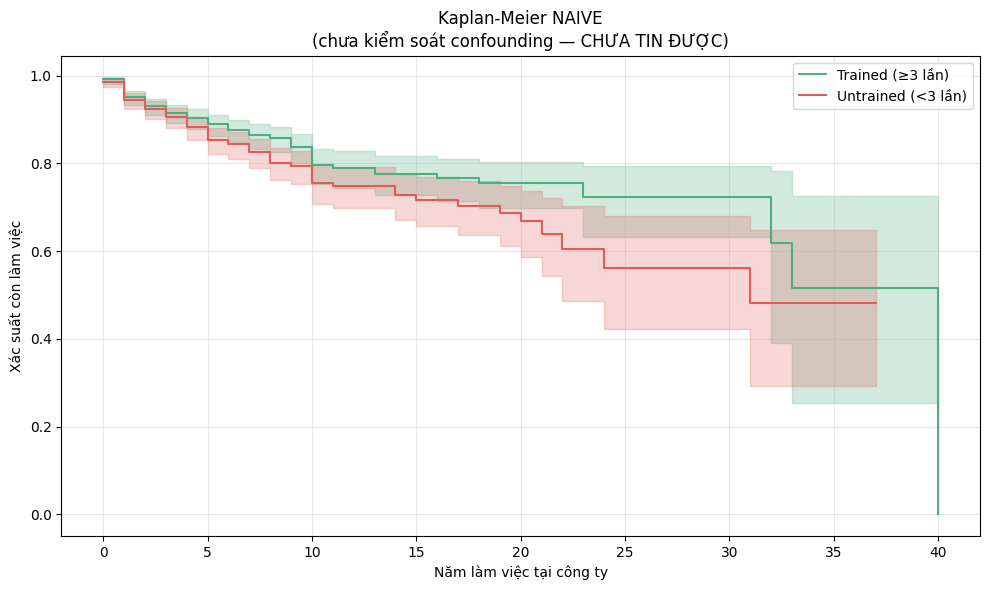

Log-rank test p-value: 0.044363
→ Khác biệt có ý nghĩa thống kê

⚠️  Kết quả này CHƯA TIN ĐƯỢC vì chưa kiểm soát selection bias
   Người được training có thể vốn đã có đặc điểm khác nhóm không training


In [5]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Chuẩn bị biến survival
df['Attrition_flag'] = (df['Attrition'] == 'Yes').astype(int)

# Kaplan-Meier NAIVE — chưa adjust confounding
# Đây là cái nhìn "raw" trước khi causal inference
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(10, 6))

for group, label, color in [(1, 'Trained (≥3 lần)', '#4caf7d'),
                              (0, 'Untrained (<3 lần)', '#e05c5c')]:
    mask = df['Trained'] == group
    kmf.fit(df.loc[mask, 'YearsAtCompany'],
            event_observed=df.loc[mask, 'Attrition_flag'],
            label=label)
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True)

plt.title('Kaplan-Meier NAIVE\n(chưa kiểm soát confounding — CHƯA TIN ĐƯỢC)', fontsize=12)
plt.xlabel('Năm làm việc tại công ty')
plt.ylabel('Xác suất còn làm việc')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/km_naive.png', dpi=150)
plt.show()

# Log-rank test
treated   = df[df['Trained']==1]
untreated = df[df['Trained']==0]
result = logrank_test(treated['YearsAtCompany'], untreated['YearsAtCompany'],
                      event_observed_A=treated['Attrition_flag'],
                      event_observed_B=untreated['Attrition_flag'])
print(f"Log-rank test p-value: {result.p_value:.6f}")
print(f"→ {'Khác biệt có ý nghĩa thống kê' if result.p_value < 0.05 else 'Không có ý nghĩa'}")
print("\n⚠️  Kết quả này CHƯA TIN ĐƯỢC vì chưa kiểm soát selection bias")
print("   Người được training có thể vốn đã có đặc điểm khác nhóm không training")

In [6]:
# ── Redefine treatment: loại bỏ vùng mơ hồ ──
df_clean = df[df['TrainingTimesLastYear'] != 2].copy()
df_clean['Treated'] = (df_clean['TrainingTimesLastYear'] >= 3).astype(int)

print(f"Dataset sau khi trim: {len(df_clean)} nhân viên")
print(f"Treated (≥3 lần): {df_clean['Treated'].sum()}")
print(f"Control (≤1 lần): {(df_clean['Treated']==0).sum()}")
print(f"Events (Attrition): {df_clean['Attrition_flag'].sum()}")

# ── Kiểm tra confounders tiềm năng ──
# Đây là bước quan trọng nhất trước khi build propensity score model
# Câu hỏi: Hai nhóm Treated/Control có khác nhau về đặc điểm quan sát không?

confounders = ['Age', 'MonthlyIncome', 'JobLevel', 'TotalWorkingYears',
               'YearsAtCompany', 'OverTime', 'JobSatisfaction',
               'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement']

print("\n=== SO SÁNH ĐẶC ĐIỂM GIỮA 2 NHÓM (TRƯỚC MATCHING) ===")
for col in confounders:
    if df_clean[col].dtype == 'object':
        # Categorical: tỷ lệ
        treated_rate = (df_clean[df_clean['Treated']==1][col] == 'Yes').mean()
        control_rate = (df_clean[df_clean['Treated']==0][col] == 'Yes').mean()
        print(f"{col:30s}: Treated={treated_rate:.3f}, Control={control_rate:.3f}, "
              f"Diff={abs(treated_rate-control_rate):.3f}")
    else:
        # Numeric: mean
        treated_mean = df_clean[df_clean['Treated']==1][col].mean()
        control_mean = df_clean[df_clean['Treated']==0][col].mean()
        std_pool = df_clean[col].std()
        smd = abs(treated_mean - control_mean) / std_pool
        flag = "⚠️  CONFOUNDER" if smd > 0.1 else "✓"
        print(f"{col:30s}: Treated={treated_mean:.2f}, Control={control_mean:.2f}, "
              f"SMD={smd:.3f} {flag}")

Dataset sau khi trim: 923 nhân viên
Treated (≥3 lần): 798
Control (≤1 lần): 125
Events (Attrition): 139

=== SO SÁNH ĐẶC ĐIỂM GIỮA 2 NHÓM (TRƯỚC MATCHING) ===
Age                           : Treated=37.11, Control=37.46, SMD=0.037 ✓
MonthlyIncome                 : Treated=6404.68, Control=6516.42, SMD=0.024 ✓
JobLevel                      : Treated=2.04, Control=2.05, SMD=0.005 ✓
TotalWorkingYears             : Treated=11.20, Control=11.55, SMD=0.045 ✓
YearsAtCompany                : Treated=7.12, Control=6.67, SMD=0.073 ✓
OverTime                      : Treated=0.256, Control=0.280, Diff=0.024
JobSatisfaction               : Treated=2.70, Control=2.79, SMD=0.083 ✓
EnvironmentSatisfaction       : Treated=2.73, Control=2.62, SMD=0.101 ⚠️  CONFOUNDER
WorkLifeBalance               : Treated=2.78, Control=2.72, SMD=0.083 ✓
JobInvolvement                : Treated=2.74, Control=2.85, SMD=0.155 ⚠️  CONFOUNDER


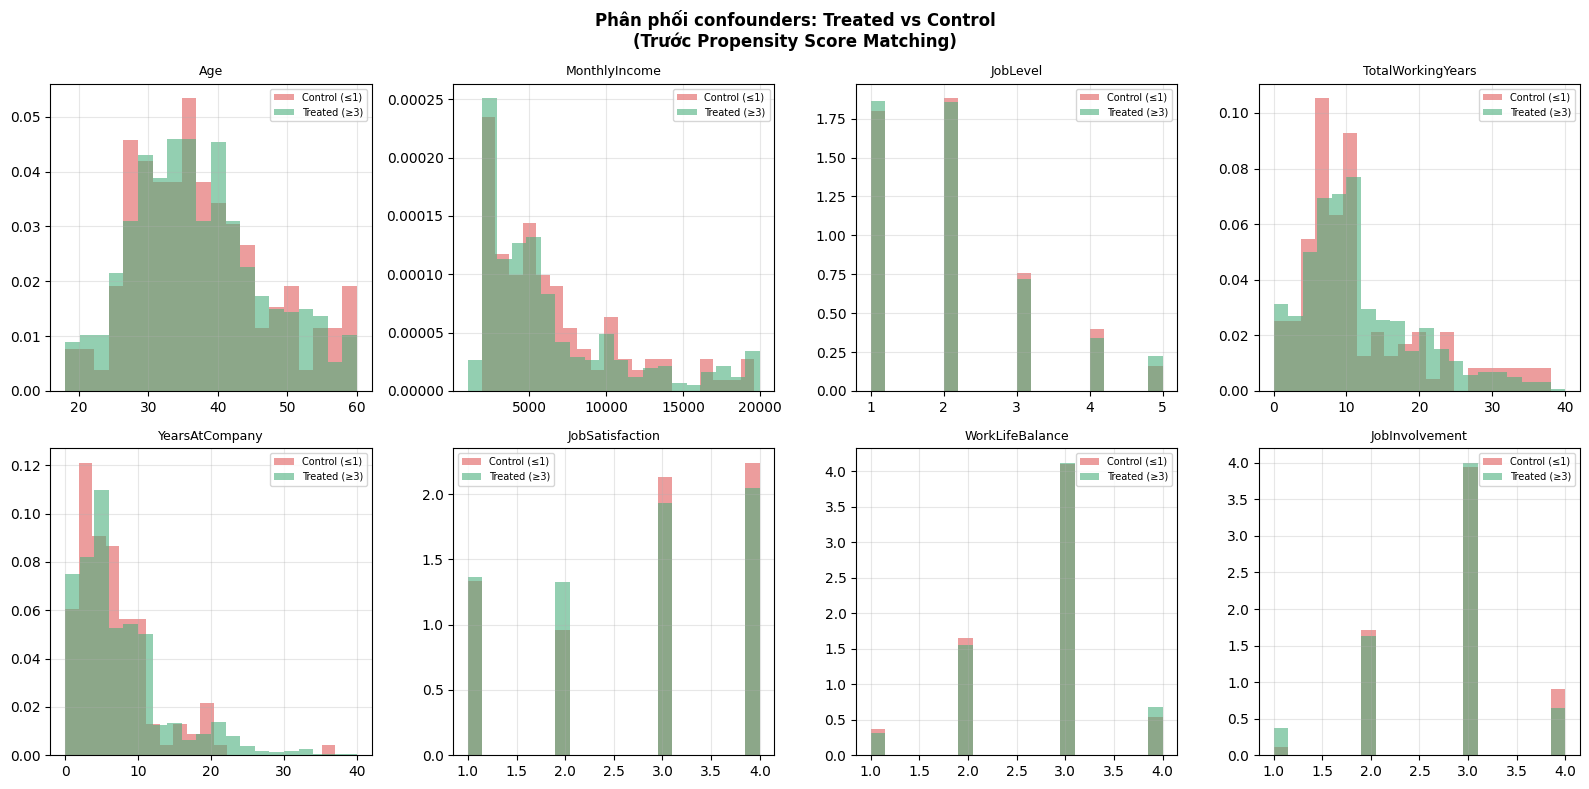

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

numeric_confounders = ['Age', 'MonthlyIncome', 'JobLevel', 'TotalWorkingYears',
                       'YearsAtCompany', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement']

for i, col in enumerate(numeric_confounders):
    treated_vals = df_clean[df_clean['Treated']==1][col]
    control_vals = df_clean[df_clean['Treated']==0][col]

    axes[i].hist(control_vals, bins=20, alpha=0.6, color='#e05c5c',
                 label='Control (≤1)', density=True)
    axes[i].hist(treated_vals, bins=20, alpha=0.6, color='#4caf7d',
                 label='Treated (≥3)', density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Phân phối confounders: Treated vs Control\n(Trước Propensity Score Matching)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/confounders_before_matching.png', dpi=150)
plt.show()

Full dataset: 1470 nhân viên
Treated (≥3): 798
Control (<3): 672

Model accuracy: 0.562

Propensity Score distribution:
  Treated: mean=0.550, std=0.058
  Control: mean=0.535, std=0.061


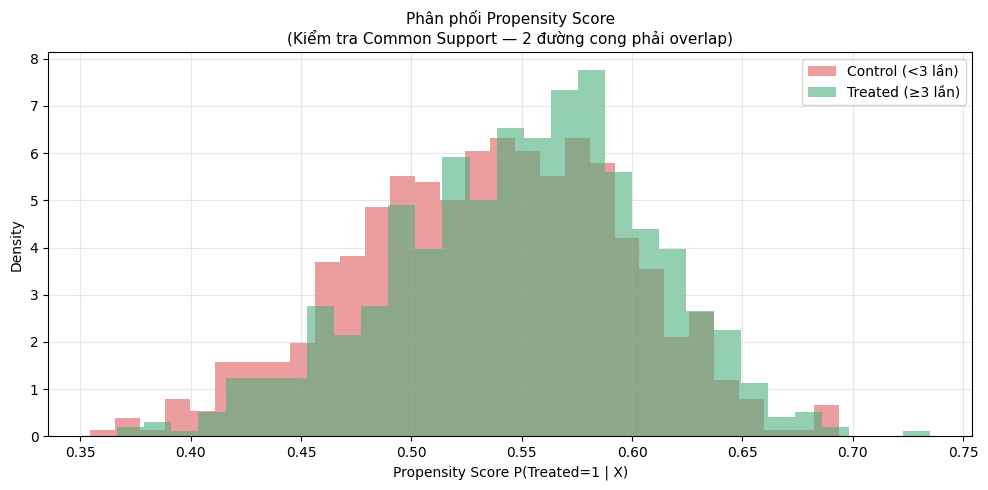

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Reset: dùng full dataset với threshold gốc ──
df['Treated'] = (df['TrainingTimesLastYear'] >= 3).astype(int)

print(f"Full dataset: {len(df)} nhân viên")
print(f"Treated (≥3): {df['Treated'].sum()}")
print(f"Control (<3): {(df['Treated']==0).sum()}")

# ── Encode features cho Propensity Score Model ──
# Chỉ dùng biến có thể là confounder (ảnh hưởng cả treatment lẫn outcome)
# KHÔNG dùng biến là mediator (nằm trên causal path giữa treatment và outcome)

df_ps = df.copy()

# Encode categorical
df_ps['OverTime_enc']       = (df_ps['OverTime'] == 'Yes').astype(int)
df_ps['Gender_enc']         = (df_ps['Gender'] == 'Male').astype(int)
df_ps['MaritalSingle']      = (df_ps['MaritalStatus'] == 'Single').astype(int)
df_ps['Travel_freq']        = (df_ps['BusinessTravel'] == 'Travel_Frequently').astype(int)

# Features cho PSM — confounders đã xác định + các biến demographic
ps_features = [
    'Age', 'MonthlyIncome', 'JobLevel', 'TotalWorkingYears',
    'YearsAtCompany', 'JobSatisfaction', 'EnvironmentSatisfaction',
    'WorkLifeBalance', 'JobInvolvement', 'NumCompaniesWorked',
    'DistanceFromHome', 'OverTime_enc', 'Gender_enc',
    'MaritalSingle', 'Travel_freq', 'StockOptionLevel',
    'YearsSinceLastPromotion', 'PercentSalaryHike'
]

X = df_ps[ps_features]
T = df_ps['Treated']

# ── Fit Logistic Regression để tính Propensity Score ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ps_model = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
ps_model.fit(X_scaled, T)

# Propensity Score = P(Treated=1 | X)
df_ps['propensity_score'] = ps_model.predict_proba(X_scaled)[:, 1]

print(f"\nModel accuracy: {ps_model.score(X_scaled, T):.3f}")
print(f"\nPropensity Score distribution:")
print(f"  Treated: mean={df_ps[df_ps['Treated']==1]['propensity_score'].mean():.3f}, "
      f"std={df_ps[df_ps['Treated']==1]['propensity_score'].std():.3f}")
print(f"  Control: mean={df_ps[df_ps['Treated']==0]['propensity_score'].mean():.3f}, "
      f"std={df_ps[df_ps['Treated']==0]['propensity_score'].std():.3f}")

# ── Kiểm tra Common Support (overlap assumption) ──
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_ps[df_ps['Treated']==0]['propensity_score'],
        bins=30, alpha=0.6, color='#e05c5c', label='Control (<3 lần)', density=True)
ax.hist(df_ps[df_ps['Treated']==1]['propensity_score'],
        bins=30, alpha=0.6, color='#4caf7d', label='Treated (≥3 lần)', density=True)
ax.set_title('Phân phối Propensity Score\n(Kiểm tra Common Support — 2 đường cong phải overlap)', fontsize=11)
ax.set_xlabel('Propensity Score P(Treated=1 | X)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/propensity_score_overlap.png', dpi=150)
plt.show()

In [9]:
from scipy.spatial.distance import cdist

np.random.seed(42)

treated_idx = df_ps[df_ps['Treated']==1].index.tolist()
control_idx = df_ps[df_ps['Treated']==0].index.tolist()

treated_ps = df_ps.loc[treated_idx, 'propensity_score'].values
control_ps = df_ps.loc[control_idx, 'propensity_score'].values

# ── Nearest Neighbor Matching với caliper ──
# Caliper = 0.2 × std(PS) — chuẩn Rosenbaum & Rubin 1985
caliper = 0.2 * df_ps['propensity_score'].std()
print(f"Caliper: {caliper:.4f}")

matched_treated = []
matched_control = []
used_control    = set()

# Shuffle treated để tránh bias theo thứ tự
treated_shuffled = np.random.permutation(len(treated_idx))

for i in treated_shuffled:
    t_ps   = treated_ps[i]
    t_idx  = treated_idx[i]

    # Tính khoảng cách PS đến tất cả control chưa dùng
    dists  = np.abs(control_ps - t_ps)

    # Lọc trong caliper và chưa dùng
    valid  = [(j, dists[j]) for j in range(len(control_idx))
              if j not in used_control and dists[j] <= caliper]

    if valid:
        # Chọn control gần nhất
        best_j = min(valid, key=lambda x: x[1])[0]
        matched_treated.append(t_idx)
        matched_control.append(control_idx[best_j])
        used_control.add(best_j)

print(f"\nKết quả matching:")
print(f"  Treated được match: {len(matched_treated)}/{len(treated_idx)}")
print(f"  Control được dùng: {len(matched_control)}/{len(control_idx)}")
print(f"  Tỷ lệ match thành công: {len(matched_treated)/len(treated_idx):.1%}")

# ── Tạo matched dataset ──
matched_idx = matched_treated + matched_control
df_matched  = df_ps.loc[matched_idx].copy()
df_matched['match_group'] = (['treated'] * len(matched_treated) +
                              ['control'] * len(matched_control))

print(f"\nMatched dataset: {len(df_matched)} nhân viên")
print(f"  Treated: {(df_matched['Treated']==1).sum()}")
print(f"  Control: {(df_matched['Treated']==0).sum()}")
print(f"  Events (Attrition): {df_matched['Attrition_flag'].sum()}")

Caliper: 0.0120

Kết quả matching:
  Treated được match: 638/798
  Control được dùng: 638/672
  Tỷ lệ match thành công: 79.9%

Matched dataset: 1276 nhân viên
  Treated: 638
  Control: 638
  Events (Attrition): 217


Feature                        SMD Before  SMD After  Balanced?
Age                                 0.045      0.025          ✅
MonthlyIncome                       0.046      0.016          ✅
JobLevel                            0.042      0.017          ✅
TotalWorkingYears                   0.023      0.016          ✅
YearsAtCompany                      0.041      0.024          ✅
JobSatisfaction                     0.058      0.009          ✅
EnvironmentSatisfaction             0.008      0.014          ✅
WorkLifeBalance                     0.049      0.020          ✅
JobInvolvement                      0.029      0.004          ✅
NumCompaniesWorked                  0.072      0.004          ✅
DistanceFromHome                    0.092      0.024          ✅
StockOptionLevel                    0.008      0.004          ✅
YearsSinceLastPromotion             0.021      0.030          ✅
Mean SMD                            0.041      0.016


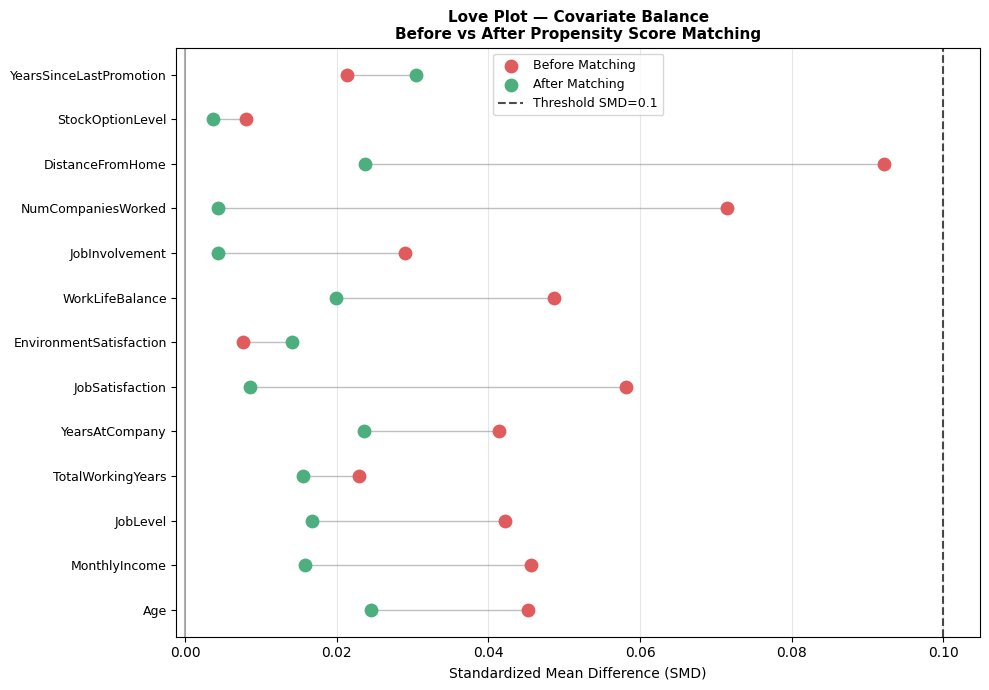

In [10]:
# ── SMD trước và sau matching — đây là bằng chứng matching hiệu quả ──
numeric_features = ['Age', 'MonthlyIncome', 'JobLevel', 'TotalWorkingYears',
                    'YearsAtCompany', 'JobSatisfaction', 'EnvironmentSatisfaction',
                    'WorkLifeBalance', 'JobInvolvement', 'NumCompaniesWorked',
                    'DistanceFromHome', 'StockOptionLevel', 'YearsSinceLastPromotion']

print("=" * 75)
print(f"{'Feature':<30} {'SMD Before':>10} {'SMD After':>10} {'Balanced?':>10}")
print("=" * 75)

smd_before_list = []
smd_after_list  = []

for col in numeric_features:
    # Before matching
    t_mean_b = df_ps[df_ps['Treated']==1][col].mean()
    c_mean_b = df_ps[df_ps['Treated']==0][col].mean()
    std_b    = df_ps[col].std()
    smd_b    = abs(t_mean_b - c_mean_b) / std_b

    # After matching
    t_mean_a = df_matched[df_matched['Treated']==1][col].mean()
    c_mean_a = df_matched[df_matched['Treated']==0][col].mean()
    std_a    = df_matched[col].std()
    smd_a    = abs(t_mean_a - c_mean_a) / std_a if std_a > 0 else 0

    balanced = "✅" if smd_a < 0.1 else "⚠️"
    print(f"{col:<30} {smd_b:>10.3f} {smd_a:>10.3f} {balanced:>10}")
    smd_before_list.append(smd_b)
    smd_after_list.append(smd_a)

print("=" * 75)
print(f"{'Mean SMD':<30} {np.mean(smd_before_list):>10.3f} {np.mean(smd_after_list):>10.3f}")

# ── Love Plot — visualization chuẩn trong causal inference literature ──
fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(len(numeric_features))

ax.scatter(smd_before_list, y_pos, color='#e05c5c', s=80,
           label='Before Matching', zorder=5)
ax.scatter(smd_after_list,  y_pos, color='#4caf7d', s=80,
           label='After Matching',  zorder=5)

for i in y_pos:
    ax.plot([smd_before_list[i], smd_after_list[i]], [i, i],
            color='gray', alpha=0.5, linewidth=1)

ax.axvline(x=0.1, color='black', linestyle='--', alpha=0.7, label='Threshold SMD=0.1')
ax.axvline(x=0.0, color='black', linestyle='-',  alpha=0.3)
ax.set_yticks(y_pos)
ax.set_yticklabels(numeric_features, fontsize=9)
ax.set_xlabel('Standardized Mean Difference (SMD)', fontsize=10)
ax.set_title('Love Plot — Covariate Balance\nBefore vs After Propensity Score Matching',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../reports/love_plot_balance.png', dpi=150)
plt.show()

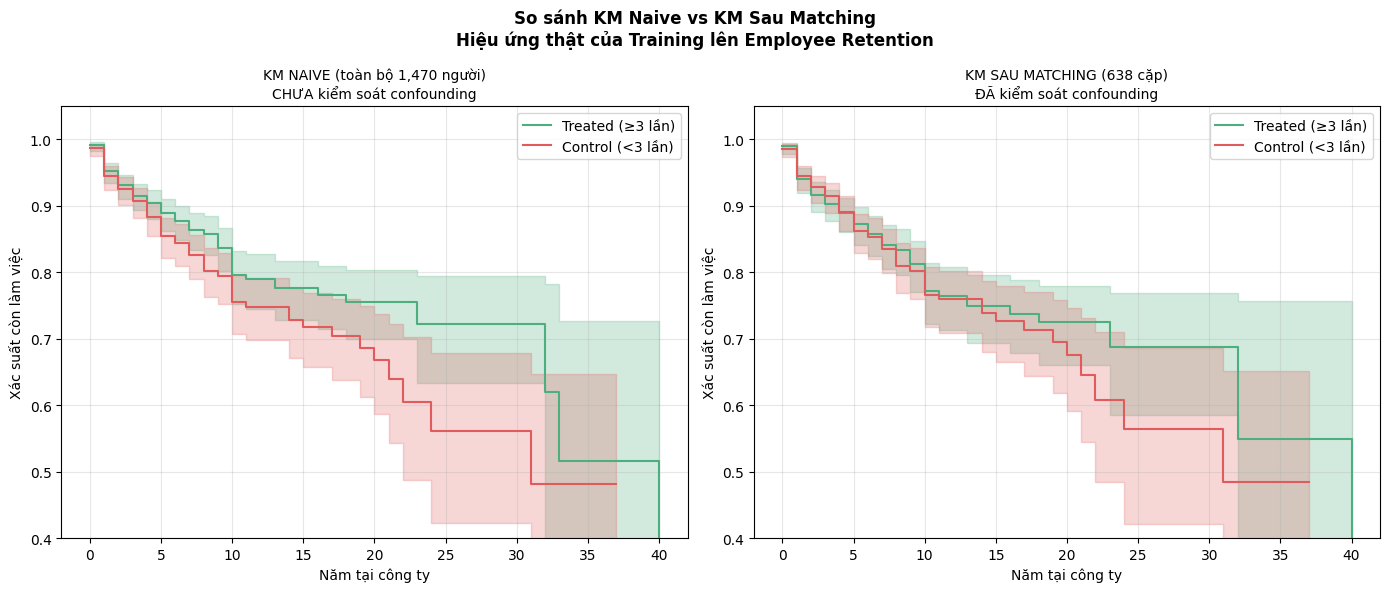

LOG-RANK TEST: NAIVE vs SAU MATCHING
Naive   p-value: 0.044363   Significant
Matched p-value: 0.570309   NOT significant

⚡ KẾT LUẬN QUAN TRỌNG:
   Effect naive là do SELECTION BIAS
   Sau khi kiểm soát confounding → training KHÔNG có
   effect thật sự lên retention

COX PH TRÊN MATCHED SAMPLE


<lifelines.CoxPHFitter: fitted with 1276 total observations, 1059 right-censored observations>
             duration col = 'YearsAtCompany'
                event col = 'Attrition_flag'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1276
number of events observed = 217
   partial log-likelihood = -1280.7512
         time fit was run = 2026-06-24 08:59:10 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                  
Treated                 -0.0655    0.9366    0.1083         -0.2778          0.1467              0.7575              1.1580
Age                     -0.0173    0.9829    0.0070         -0.0311         -0.0035              0.9694              0.9965
MonthlyIncome           -0.0000    1.0000    0.0000         -0.0001         -0.0000              0.9999              1.0000
JobLevel                -0.2402    0.7865    0.0652         -0.3679         -0.1125              0.6922              0.8936
OverTime_enc             0.7576    2.1331    0.1120          0.5381          0.9771              1.7127              2.6568
JobSatisfaction         -0.1618    0.8506    0.0483         -0.2564         -0.0672              0.7738              0.9350
EnvironmentSatisfaction -0.1245    0.8829    0.0485         -0.2196         -0.0295              0.8029              0.9709
WorkLifeBalance         -0.1155    0.8909    0.0758         -0.2640          0.0329              0.7680              1.0335
JobInvolvement          -0.2505    0.7784    0.0721         -0.3918         -0.1091              0.6758              0.8966
TotalWorkingYears       -0.0604    0.9414    0.0095         -0.0791         -0.0417              0.9240              0.9592
MaritalSingle            0.5672    1.7633    0.1114          0.3488          0.7856              1.4174              2.1937

                         cmp to       z      p  -log2(p)
covariate                                               
Treated                  0.0000 -0.6051 0.5451    0.8753
Age                      0.0000 -2.4541 0.0141    6.1459
MonthlyIncome            0.0000 -3.0133 0.0026    8.5962
JobLevel                 0.0000 -3.6868 0.0002   12.1045
OverTime_enc             0.0000  6.7644 <5e-05   36.1208
JobSatisfaction          0.0000 -3.3520 0.0008   10.2838
EnvironmentSatisfaction  0.0000 -2.5692 0.0102    6.6163
WorkLifeBalance          0.0000 -1.5251 0.1272    2.9744
JobInvolvement           0.0000 -3.4729 0.0005   10.9234
TotalWorkingYears        0.0000 -6.3297 <5e-05   31.9232
MaritalSingle            0.0000  5.0910 <5e-05   21.4212
---
Concordance = 0.8600
Partial AIC = 2583.5025
log-likelihood ratio test = 263.3768 on 11 df
-log2(p) of ll-ratio test = 163.9619


Concordance: 0.8600


In [11]:
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test, proportional_hazard_test

# ── Bước 1: KM trên MATCHED sample — so sánh với KM naive ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
kmf = KaplanMeierFitter()

for ax, (dataset, title) in zip(axes, [
    (df_ps,      'KM NAIVE (toàn bộ 1,470 người)\nCHƯA kiểm soát confounding'),
    (df_matched, 'KM SAU MATCHING (638 cặp)\nĐÃ kiểm soát confounding')
]):
    for group, label, color in [(1,'Treated (≥3 lần)','#4caf7d'),
                                  (0,'Control (<3 lần)','#e05c5c')]:
        mask = dataset['Treated'] == group
        kmf.fit(dataset.loc[mask,'YearsAtCompany'],
                event_observed=dataset.loc[mask,'Attrition_flag'],
                label=label)
        kmf.plot_survival_function(ax=ax, color=color, ci_show=True)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Năm tại công ty')
    ax.set_ylabel('Xác suất còn làm việc')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.4, 1.05)

plt.suptitle('So sánh KM Naive vs KM Sau Matching\nHiệu ứng thật của Training lên Employee Retention',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/km_naive_vs_matched.png', dpi=150)
plt.show()

# ── Bước 2: Log-rank test trên matched sample ──
treated_m   = df_matched[df_matched['Treated']==1]
control_m   = df_matched[df_matched['Treated']==0]

result_naive   = logrank_test(
    df_ps[df_ps['Treated']==1]['YearsAtCompany'],
    df_ps[df_ps['Treated']==0]['YearsAtCompany'],
    event_observed_A=df_ps[df_ps['Treated']==1]['Attrition_flag'],
    event_observed_B=df_ps[df_ps['Treated']==0]['Attrition_flag']
)
result_matched = logrank_test(
    treated_m['YearsAtCompany'], control_m['YearsAtCompany'],
    event_observed_A=treated_m['Attrition_flag'],
    event_observed_B=control_m['Attrition_flag']
)

print("=" * 55)
print("LOG-RANK TEST: NAIVE vs SAU MATCHING")
print("=" * 55)
print(f"Naive   p-value: {result_naive.p_value:.6f}   "
      f"{'Significant' if result_naive.p_value < 0.05 else 'NOT significant'}")
print(f"Matched p-value: {result_matched.p_value:.6f}   "
      f"{'Significant' if result_matched.p_value < 0.05 else 'NOT significant'}")
print()
if result_naive.p_value < 0.05 and result_matched.p_value >= 0.05:
    print("⚡ KẾT LUẬN QUAN TRỌNG:")
    print("   Effect naive là do SELECTION BIAS")
    print("   Sau khi kiểm soát confounding → training KHÔNG có")
    print("   effect thật sự lên retention")
elif result_matched.p_value < 0.05:
    print("✅ KẾT LUẬN:")
    print("   Training có CAUSAL EFFECT thật sự lên retention")
    print("   Không phải do selection bias")
else:
    print("→ Cần Cox PH để kiểm tra thêm với covariates")

# ── Bước 3: Cox PH trên matched sample ──
print("\n" + "=" * 55)
print("COX PH TRÊN MATCHED SAMPLE")
print("=" * 55)

cox_features = ['Treated', 'Age', 'MonthlyIncome', 'JobLevel',
                'OverTime_enc', 'JobSatisfaction', 'EnvironmentSatisfaction',
                'WorkLifeBalance', 'JobInvolvement', 'YearsAtCompany',
                'TotalWorkingYears', 'MaritalSingle']

df_cox_matched = df_matched[cox_features + ['Attrition_flag']].copy()

cph_matched = CoxPHFitter(penalizer=0.1)
cph_matched.fit(df_cox_matched,
                duration_col='YearsAtCompany',
                event_col='Attrition_flag')
cph_matched.print_summary(decimals=4)

print(f"\nConcordance: {cph_matched.concordance_index_:.4f}")

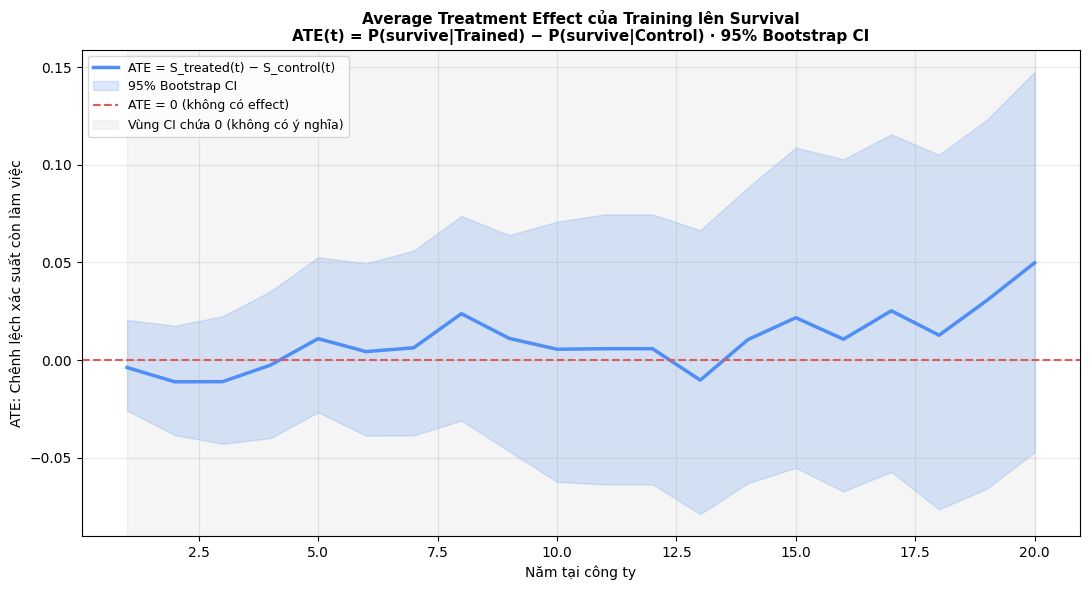


ATE tại các mốc thời gian quan trọng:
  Năm      ATE   CI Lower   CI Upper  Significant
--------------------------------------------------
    1  -0.0038    -0.0259     0.0205     ❌ chứa 0
    2  -0.0112    -0.0385     0.0176     ❌ chứa 0
    3  -0.0111    -0.0429     0.0224     ❌ chứa 0
    4  -0.0026    -0.0400     0.0352     ❌ chứa 0
    5   0.0109    -0.0267     0.0526     ❌ chứa 0
    6   0.0043    -0.0388     0.0495     ❌ chứa 0
    7   0.0062    -0.0386     0.0560     ❌ chứa 0
    8   0.0237    -0.0311     0.0738     ❌ chứa 0
    9   0.0111    -0.0467     0.0640     ❌ chứa 0
   10   0.0055    -0.0624     0.0708     ❌ chứa 0
   11   0.0058    -0.0637     0.0746     ❌ chứa 0
   12   0.0058    -0.0637     0.0746     ❌ chứa 0
   13  -0.0103    -0.0790     0.0665     ❌ chứa 0
   14   0.0105    -0.0631     0.0884     ❌ chứa 0
   15   0.0217    -0.0552     0.1088     ❌ chứa 0
   16   0.0107    -0.0673     0.1028     ❌ chứa 0
   17   0.0252    -0.0573     0.1156     ❌ chứa 0
   18   0.

In [13]:
from lifelines import KaplanMeierFitter
import numpy as np

np.random.seed(42)
n_bootstrap = 500
time_points = np.arange(1, 21)  # năm 1-20

ate_bootstrap = np.zeros((n_bootstrap, len(time_points)))

for b in range(n_bootstrap):
    # Resample matched pairs (giữ nguyên cặp — paired bootstrap)
    pair_ids  = np.random.choice(len(matched_treated), 
                                  size=len(matched_treated), replace=True)
    boot_t_idx = [matched_treated[i] for i in pair_ids]
    boot_c_idx = [matched_control[i] for i in pair_ids]
    boot_idx   = boot_t_idx + boot_c_idx
    df_boot    = df_ps.loc[boot_idx].copy()

    kmf_t = KaplanMeierFitter()
    kmf_c = KaplanMeierFitter()

    try:
        kmf_t.fit(df_boot[df_boot['Treated']==1]['YearsAtCompany'],
                  event_observed=df_boot[df_boot['Treated']==1]['Attrition_flag'])
        kmf_c.fit(df_boot[df_boot['Treated']==0]['YearsAtCompany'],
                  event_observed=df_boot[df_boot['Treated']==0]['Attrition_flag'])

        for j, t in enumerate(time_points):
            s_t = kmf_t.survival_function_at_times([t]).values[0]
            s_c = kmf_c.survival_function_at_times([t]).values[0]
            ate_bootstrap[b, j] = s_t - s_c
    except:
        ate_bootstrap[b, :] = np.nan

# ATE point estimate và CI
kmf_t_obs = KaplanMeierFitter()
kmf_c_obs = KaplanMeierFitter()
kmf_t_obs.fit(df_matched[df_matched['Treated']==1]['YearsAtCompany'],
              event_observed=df_matched[df_matched['Treated']==1]['Attrition_flag'])
kmf_c_obs.fit(df_matched[df_matched['Treated']==0]['YearsAtCompany'],
              event_observed=df_matched[df_matched['Treated']==0]['Attrition_flag'])

ate_obs = np.array([
    kmf_t_obs.survival_function_at_times([t]).values[0] -
    kmf_c_obs.survival_function_at_times([t]).values[0]
    for t in time_points
])

ci_low  = np.nanpercentile(ate_bootstrap, 2.5,  axis=0)
ci_high = np.nanpercentile(ate_bootstrap, 97.5, axis=0)

# Plot ATE với Bootstrap CI
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(time_points, ate_obs, color='#4f8ef7', linewidth=2.5,
        label='ATE = S_treated(t) − S_control(t)')
ax.fill_between(time_points, ci_low, ci_high,
                color='#4f8ef7', alpha=0.2, label='95% Bootstrap CI')
ax.axhline(y=0, color='#e05c5c', linewidth=1.5, linestyle='--',
           label='ATE = 0 (không có effect)')

# Highlight vùng CI cắt qua 0
null_cross = np.where((ci_low <= 0) & (ci_high >= 0))[0]
if len(null_cross) > 0:
    ax.axvspan(time_points[null_cross[0]], time_points[null_cross[-1]],
               alpha=0.08, color='gray', label='Vùng CI chứa 0 (không có ý nghĩa)')

ax.set_title('Average Treatment Effect của Training lên Survival\n'
             'ATE(t) = P(survive|Trained) − P(survive|Control) · 95% Bootstrap CI',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Năm tại công ty', fontsize=10)
ax.set_ylabel('ATE: Chênh lệch xác suất còn làm việc', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/ate_bootstrap_ci.png', dpi=150)
plt.show()

print("\nATE tại các mốc thời gian quan trọng:")
print(f"{'Năm':>5} {'ATE':>8} {'CI Lower':>10} {'CI Upper':>10} {'Significant':>12}")
print("-" * 50)
for i, t in enumerate(time_points):
    sig = "✅" if (ci_low[i] > 0 or ci_high[i] < 0) else "❌ chứa 0"
    print(f"{t:>5} {ate_obs[i]:>8.4f} {ci_low[i]:>10.4f} {ci_high[i]:>10.4f} {sig:>12}")

In [14]:
import pickle, os

os.makedirs('../app', exist_ok=True)

# Lưu model và data
with open('../app/cox_matched_model.pkl', 'wb') as f:
    pickle.dump(cph_matched, f)

with open('../app/ps_model.pkl', 'wb') as f:
    pickle.dump(ps_model, f)

with open('../app/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

df_matched.to_csv('../app/df_matched.csv', index=False)
df_ps.to_csv('../app/df_ps.csv', index=False)

# Lưu ATE results
ate_results = pd.DataFrame({
    'year'    : time_points,
    'ate'     : ate_obs,
    'ci_low'  : ci_low,
    'ci_high' : ci_high
})
ate_results.to_csv('../app/ate_results.csv', index=False)

print("Đã lưu:")
for fname in os.listdir('../app'):
    size = os.path.getsize(f'../app/{fname}') / 1024
    print(f"  {fname}: {size:.1f} KB")

Đã lưu:
  ate_results.csv: 1.3 KB
  cox_matched_model.pkl: 100.4 KB
  df_matched.csv: 244.6 KB
  df_ps.csv: 270.1 KB
  ps_model.pkl: 0.8 KB
  scaler.pkl: 1.2 KB
